# VLM training (v1)

Thin orchestration notebook: imports model + training code from `GPT.py`, `ViT.py`, `VLM.py`. Skips ViT pretraining (loads existing checkpoint). Reuses VLM definition, checkpoint loading, and training loop from `VLM.py`.

In [1]:
import os
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '../src')
sys.path.insert(0, '../src/model')

import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoTokenizer

from src.model.GPT import GPT
from src.model.ViT import ViT
from src.model.VLM import VLM
from src.configs import (
    ConfigParametersLLM,
    ConfigParametersViT,
    ConfigParametersVLM,
    OptimParametersVLM,
)
from src.vision_datasets import val_tfm, train_tfm, build_vlm_dataloaders, build_coco_dataloaders
from src.train_helper import validate_vlm

/home/pensativo/code/vision-ai-guide/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup: tokenizer, device, paths

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

LLM_CKPT = "../outputs/llm/llm_wikitext_final.pt"
VLM_OUTPUT_DIR = "./outputs/vlm"
DATA_DIR = "../data/coco"

if  not os.path.exists(VLM_OUTPUT_DIR):
    os.makedirs(VLM_OUTPUT_DIR, exist_ok=True)

## Build configs

In [8]:

llm_config_params = {
    "vocab_size": 50257, #vocab size of the GPT2 tokenizer on HF
    "num_blocks": 4, #number of transformer blocks
    "device": device, #device
    "chunk_size": 512, #chunk size
    "model_dim": 768, #model dimension
    "num_heads": 4, #number of heads
    "max_seq_length": 512, #max sequence length
}

vit_config_params = {
    "patch_size": 16, #patch size
    "patch_dim": 768, #patch dimension
    "num_patches": 196, #number of patches
    "num_classes": 10, #number of classes
    "device": device, #device
    "model_dim": 256, #model dimension
    "num_heads": 4, #number of heads
    "num_blocks": 4 #number of blocks
}

vlm_config_params = {
    "model_dim": 768, #model dimension
    "vision_model_dim": 256, #vision model dimension
    "device": device, #device
    "batch_size": 32, #batch size
}

#configs
llm_config = ConfigParametersLLM(**llm_config_params)
vit_config = ConfigParametersViT(**vit_config_params)
vlm_config = ConfigParametersVLM(**vlm_config_params)

In [9]:
from pathlib import Path

def load_llm_1(cfg, device, ckpt_path):                                                                                                                                                 
      model = GPT(cfg).to(device)                           
      if ckpt_path is not None:
          ckpt = torch.load(ckpt_path, map_location=device)                                                                                                                             
          state_dict = {
              k.removeprefix("_orig_mod."): v                                                                                                                                           
              for k, v in ckpt["model"].items()                                                                                                                                         
          }
          model.load_state_dict(state_dict)                                                                                                                                             
      return model                                          


def load_llm(
    cfg: ConfigParametersLLM,
    device: torch.device | str,
    ckpt_path: str | Path,
) -> GPT:
    """Build a GPT and load weights from disk."""
    model = GPT(cfg).to(device)

    if ckpt_path is not None:
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
    return model


def load_vit(
    cfg,
    device: torch.device | str,
    ckpt_path: str | Path,
):
    """Build a ViT and load weights from disk."""
   
    model = ViT(cfg).to(device)
    if ckpt_path is not None:
        ckpt = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model"])
    return model


def build_vlm(
    vit_model,
    llm_model,
    cfg: ConfigParametersVLM,
    device: torch.device | str,
) -> VLM:
    """Wrap the ViT + LLM in a VLM, on the given device."""
    cfg.vision_encoder = vit_model
    cfg.LLM = llm_model
    return VLM(cfg).to(device)

## Load LLM and ViT checkpoint 

In [10]:
llm_model = load_llm_1(llm_config, device, LLM_CKPT)
print(f"loaded LLM")

vit_model = load_vit(vit_config, device, ckpt_path=None)
print(f"loaded ViT")

loaded LLM
loaded ViT


## Build VLM and optimizer

In [11]:
vlm_model = build_vlm(vit_model, llm_model, vlm_config, device)


#set optimizer hyperparameters
optim_config = {
    "lr": 1e-4, #learning rate
    "min_lr": 1e-5, #minimum learning rate
    "betas": (0.9, 0.95), #betas
    "eps": 1e-8, #epsilon
    "scheduler": True, #use a learning rate scheduler
    "compile": True, #compile the model
    "autocast": True, #autocast
    "autocast_dtype": torch.bfloat16, #autocast dtype
    "min_lr": 1e-5, #minimum learning rate
    "warmup_steps": 500, #warmup steps
    "max_steps": 40000 #max steps
}

opt_cfg = OptimParametersVLM(**optim_config)
optimizer = torch.optim.AdamW(
    [p for p in vlm_model.parameters() if p.requires_grad],
    lr=opt_cfg.lr, betas=opt_cfg.betas, eps=opt_cfg.eps,
)

scheduler = None
if opt_cfg.scheduler is not None:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=opt_cfg.max_steps)

if opt_cfg.compile is not None:
    vlm_model = torch.compile(vlm_model)

## Build dataloaders

In [14]:
train_loader, val_loader = build_coco_dataloaders(                                                                                                                                    
      tokenizer,
      batch_size=vlm_config.batch_size,                                                                                                                                                                    
      num_workers=4, 
      data_dir=DATA_DIR,                                       
      # val_limit=500 by default — 500 pairs for quick eval
      # train_limit=None      — use all 591K train pairs                                                                                                                                
  )
print(f"train batches: {len(train_loader):,}")   # ~18,500 at batch=32                                                                                                                
print(f"val batches:   {len(val_loader):,}")     # ~16 at batch=32, val_limit=500 
print(f"train batches: {len(train_loader)}")
print(f"val batches:   {len(val_loader)}")

train batches: 18,493
val batches:   16
train batches: 18493
val batches:   16


## Train VLM

In [9]:
def save_checkpoint(
    ckpt_path: str, 
    step: int, 
    model: torch.nn.Module, 
    optimizer: torch.optim.Optimizer, 
    scheduler: torch.optim.lr_scheduler.LRScheduler, 
    train_loss: list,
    opt_cfg: OptimParametersVLM)->None:

    """Save the model, optimizer, and scheduler state dictionaries to a checkpoint file.
    Args:
        ckpt_path: str, path to save the checkpoint file
        step: int, current step number
        model: torch.nn.Module, model to save
        optimizer: torch.optim.Optimizer, optimizer to save
        scheduler: torch.optim.lr_scheduler.LRScheduler, scheduler to save
        train_loss: list, training loss values
    """
    if opt_cfg.compile is not None:
        raw_model = getattr(model, "_orig_mod", model) 

    payload = {    
        "step": step,
        "model": raw_model.state_dict(),
        "train_loss": train_loss,
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict() if scheduler is not None else None
    }
    tmp = ckpt_path + ".tmp"
    torch.save(payload, tmp)                                                                                                                                                          
    os.replace(tmp, ckpt_path)

In [10]:
def train_vlm(model, train_loader, val_loader=None, optimizer=None, device=None, max_steps=None, validation=True):
    model.train()
    step = 0
    train_loss: list[float] = []
    val_loss: list[float] = []
    print_every = max_steps // 20
    save_every = max_steps // 10

    while step < max_steps:
        for img, text_tokens, attention_mask, targets in train_loader:
            img = img.to(device)
            text_tokens = text_tokens.to(device)
            attention_mask = attention_mask.to(device)
            targets = targets.to(device)
            
            #autocast to bf16 for faster training
            if opt_cfg.autocast is not None:
                with torch.autocast(device_type="cuda", dtype=opt_cfg.autocast_dtype):     
                    logits, loss = model(
                                    x_img=img, x_text=text_tokens,
                                    targets=targets, attention_mask=attention_mask,
                                    )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()  
            if opt_cfg.scheduler:                                                                                                                                                          
                scheduler.step() 

            train_loss.append(loss.item())
            step += 1

            if step % print_every == 0:
                print(f"Step {step} | Loss {loss.item():.4f}")
        
            if step % save_every == 0:
                ckpt_path = os.path.join(VLM_OUTPUT_DIR, f"vlm_coco_captions{step:07d}.pt")
                save_checkpoint(
                    ckpt_path=os.path.join(VLM_OUTPUT_DIR, f"vlm_coco_captions{step:07d}.pt"),
                    step=step,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    train_loss=train_loss,
                    opt_cfg=opt_cfg
                )

                print(f"Checkpoint saved at step {step}")


                #validation
                
                if val_loader is not None and validation:
                    autocast_dtype = opt_cfg.autocast_dtype
                    vlm_model.eval()
                    with torch.inference_mode():
                        v_loss = validate_vlm(                                                                                                                                                          
                                vlm_model, val_loader, device,
                                max_batches=20,                       # ~640 caption pairs at batch=32                                                                                                        
                                autocast_dtype=autocast_dtype
                            )                                                                                                                                            
                        print(f"Validation loss: {v_loss:.4f}")
                        val_loss.append(v_loss)
                    vlm_model.train()
            

            if step >= max_steps:
                break

    ckpt_path = os.path.join(VLM_OUTPUT_DIR, "vlm_coco_captions_final.pt")
    torch.save(
        {"step": step, "model": model.state_dict(), "train_loss": train_loss},
        ckpt_path,
    )
    print(f"Saved checkpoint to {ckpt_path}")
    return train_loss, val_loss

In [11]:
train_loss, val_loss = train_vlm(vlm_model, train_loader, val_loader, optimizer, device, max_steps=opt_cfg.max_steps, validation=True)

W0426 21:22:30.313000 152843 torch/_inductor/utils.py:1727] [0/0_1] Not enough SMs to use max_autotune_gemm mode


Step 2000 | Loss 2.8397
Step 4000 | Loss 2.5833
Checkpoint saved at step 4000
Validation loss: 3.0770
Step 6000 | Loss 2.6138
Step 8000 | Loss 2.6530
Checkpoint saved at step 8000
Validation loss: 2.9288
Step 10000 | Loss 2.9016
Step 12000 | Loss 2.9073
Checkpoint saved at step 12000
Validation loss: 2.9013
Step 14000 | Loss 2.4797
Step 16000 | Loss 2.4314
Checkpoint saved at step 16000
Validation loss: 2.8618
Step 18000 | Loss 2.7580
Step 20000 | Loss 2.4743
Checkpoint saved at step 20000
Validation loss: 2.8103
Step 22000 | Loss 2.5953
Step 24000 | Loss 2.3393
Checkpoint saved at step 24000
Validation loss: 2.7666
Step 26000 | Loss 2.2919
Step 28000 | Loss 2.4421
Checkpoint saved at step 28000
Validation loss: 2.7369
Step 30000 | Loss 2.4278
Step 32000 | Loss 2.0107
Checkpoint saved at step 32000
Validation loss: 2.7180
Step 34000 | Loss 2.3461
Step 36000 | Loss 2.4876
Checkpoint saved at step 36000
Validation loss: 2.6995
Step 38000 | Loss 1.8725
Step 40000 | Loss 2.2499
Checkpoint 

In [15]:
# ---------------------------------------------------------------------------
# Inference helper
# ---------------------------------------------------------------------------

def prepare_inference_input(
    messages: list[dict],
    tokenizer,
    max_len: int,
    transform,
    root: str | None = None,
) -> dict:
    """Convert a chat-style message into VLM model inputs (single sample)."""
    content = messages[0]["content"]
    img = None
    text = None

    for item in content:
        if item["type"] == "image":
            image_path = item.get("path") or item.get("url")
            if root is not None and not os.path.isabs(image_path):
                image_path = os.path.join(root, image_path)
            img = Image.open(image_path).convert("RGB")
            img = transform(img)
        elif item["type"] == "text":
            text = item["text"]

    text_ids = tokenizer(text, add_special_tokens=False)["input_ids"][:max_len]
    text_tokens = torch.tensor(text_ids, dtype=torch.long).unsqueeze(0)

    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    attention_mask = torch.ones_like(text_tokens)

    return {
        "image": img.unsqueeze(0),
        "text_tokens": text_tokens,
        "attention_mask": attention_mask,
    }

## Plot training loss

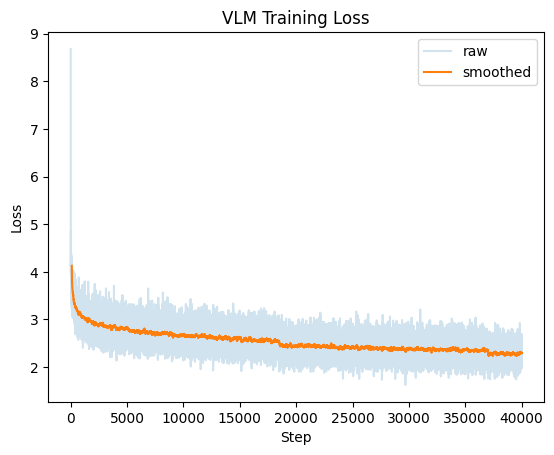

In [13]:
window = 100
if len(train_loss) >= window:
    smoothed = [
        sum(train_loss[i:i+window]) / window
        for i in range(len(train_loss) - window + 1)
    ]
    plt.plot(train_loss, alpha=0.2, label="raw")
    plt.plot(range(window - 1, len(train_loss)), smoothed, label="smoothed")
else:
    plt.plot(train_loss, label="raw")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("VLM Training Loss")
plt.legend()
plt.show()

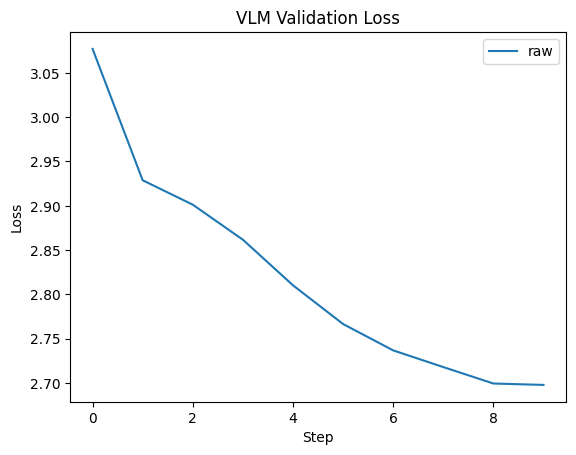

In [14]:
window = 100
if len(val_loss) >= window:
    smoothed = [
        sum(val_loss[i:i+window]) / window
        for i in range(len(val_loss) - window + 1)
    ]
    plt.plot(val_loss, alpha=0.2, label="raw")
    plt.plot(range(window - 1, len(val_loss)), smoothed, label="smoothed")
else:
    plt.plot(val_loss, label="raw")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("VLM Validation Loss")
plt.legend()
plt.show()

## Inference test

In [21]:
#load VLM model
ckpt = torch.load("../outputs/vlm/vlm_coco_captions_final.pt")
state_dict = {k.removeprefix("_orig_mod."): v for k, v in ckpt["model"].items()}
                                              
vlm_model = build_vlm(vit_model, llm_model, vlm_config, device)                                                                                                                       
vlm_model.load_state_dict(state_dict)                                                                                                                                                 
vlm_model.to(device)                                                                                                                                                                  
vlm_model.eval()  

VLM(
  (vision_encoder): ViT(
    (blocks): ModuleList(
      (0-3): 4 x TransformerBlock(
        (MHSA): MultiHeadAttention(
          (q_proj): Linear()
          (k_proj): Linear()
          (v_proj): Linear()
          (o_proj): Linear()
        )
        (layernorm1): LayerNormalization()
        (layernorm2): LayerNormalization()
        (FFN): Sequential(
          (0): Linear()
          (1): GLU()
          (2): Linear()
        )
      )
    )
    (logit_proj): Linear()
    (x_proj): Linear()
    (pos_emb): Embedding(197, 256)
  )
  (LLM): GPT(
    (blocks): ModuleList(
      (0-3): 4 x TransformerBlock(
        (MHSA): MultiHeadAttention(
          (q_proj): Linear()
          (k_proj): Linear()
          (v_proj): Linear()
          (o_proj): Linear()
        )
        (layernorm1): LayerNormalization()
        (layernorm2): LayerNormalization()
        (FFN): Sequential(
          (0): Linear()
          (1): GLU()
          (2): Linear()
        )
      )
    )
    (logi

text_tokens: [32, 3797, 5586, 319, 257, 4675, 5228, 2045, 379, 262, 4676, 13, 50256]
caption (decoded): 'A cat sitting on a street corner looking at the camera.'

image path: ../data/coco/val2017/000000255965.jpg
caption used at idx 110: 'A cat sitting on a street corner looking at the camera.'


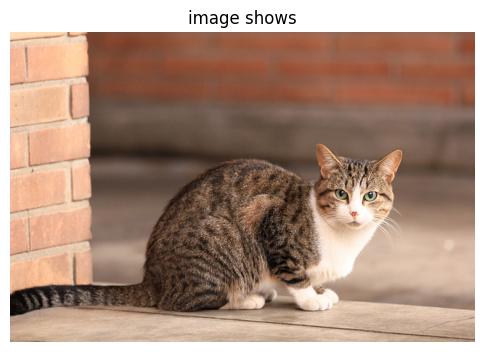

 a cat sitting on a wooden bench


In [32]:
idx = 110                                                                                                                                      
                                                                                                                                                                                        
# Inspect what the dataloader sees       
val_ds  = val_loader.dataset                                                                                                                                             
sample = val_ds[idx]                                                                                                                                                                  
print(f"text_tokens: {sample['text_tokens'].tolist()}")                                                                                                                               
print(f"caption (decoded): {tokenizer.decode(sample['text_tokens'], skip_special_tokens=True)!r}")                                                                                    
                                                                                                                                                                                        
# Image path + all reference captions for this image                                                                                                                                  
file_name, caption_used = val_ds.samples[idx]                                                                                                                                         
image_path = os.path.join(val_ds.image_dir, file_name)                                                                                                                                
print(f"\nimage path: {image_path}")                                                                                                                                                  
print(f"caption used at idx {idx}: {caption_used!r}") 

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "path": image_path,
            },
            {
                "type": "text",
                "text": "image shows"
            },
        ],
    }
]

vlm_model.eval()
inputs = prepare_inference_input(messages, tokenizer, max_len=512, transform=val_tfm)
image = inputs["image"].to(device)
text_tokens = inputs["text_tokens"].to(device)
attention_mask = inputs["attention_mask"].to(device)

with torch.inference_mode():
    generated_ids = vlm_model.generate(
        image,
        text_tokens,
        attention_mask,
        max_new_tokens=100,
        eos_token_id=tokenizer.eos_token_id,
    )

image_path = messages[0]["content"][0]["path"]
prompt_text = messages[0]["content"][1]["text"]

pil_img = Image.open(image_path).convert("RGB")
plt.figure(figsize=(6, 6))
plt.imshow(pil_img)
plt.axis("off")
plt.title(prompt_text)
plt.show()

print(tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0])